# RetinaNet 모델

In [1]:
### 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 0. 환경 준비
!nvidia-smi

Wed Mar 25 07:13:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   35C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### git 연결

In [3]:
# 1. 내 포크 clone
!git clone https://github.com/wina0901/pill_detection_project.git

# 2. 프로젝트 폴더로 이동
%cd pill_detection_project

# 3. requirements 설치
!pip install --upgrade pip
!pip install --index-url https://download.pytorch.org/whl/cu118 torch==2.7.1+cu118 torchvision==0.22.1+cu118 torchaudio==2.7.1+cu118
!pip install -r requirements.txt --no-deps


Cloning into 'pill_detection_project'...
remote: Enumerating objects: 488, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 488 (delta 4), reused 2 (delta 2), pack-reused 472 (from 2)
Receiving objects: 100% (488/488), 34.94 MiB | 26.66 MiB/s, done.
Resolving deltas: 100% (188/188), done.
/content/pill_detection_project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 171.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 50.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 219.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 43.0 MB/s  0:00:07:00:010

In [4]:
import sys
import os
sys.path.append("/content/pill_detection_project")

from src.evaluation import (
    evaluate_all,
    init_history,
    update_history,
    save_history,
    load_history,
    plot_training_history,
    plot_compare_histories,
    convert_yolo_results,
    convert_torchvision_outputs,
)


# 데이터 가져오기

In [5]:
import os
from src.preprocessing.dataset import get_loaders

BASE_DIR = '/content/drive/MyDrive/data/초급_프로젝트/dataset'  # Colab 기준

train_loader, val_loader, orig2model, num_classes, VAL_JSON_PATH = get_loaders(
    base_dir=BASE_DIR,
    batch_size=4,
    num_workers=2,
)

✅ 고유 클래스 수  : 73종
✅ num_classes     : 74  ← 모델 정의 시 사용
✅ Train: 1776장 / 6105개
✅ Val  : 149장 / 470개


# 모델 학습

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [7]:
############################################################
# RetinaNet
############################################################

import math
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchvision.ops import sigmoid_focal_loss


class CustomRetinaNetClassificationHead(RetinaNetClassificationHead):
    def __init__(self, in_channels, num_anchors, num_classes, alpha=0.25, gamma=2.0, norm_layer=None):
        super().__init__(in_channels, num_anchors, num_classes, norm_layer=norm_layer)
        self.focal_alpha = alpha
        self.focal_gamma = gamma

    def compute_loss(self, targets, head_outputs, matched_idxs):
        cls_logits = head_outputs["cls_logits"]
        losses = []

        for targets_per_image, cls_logits_per_image, matched_idxs_per_image in zip(targets, cls_logits, matched_idxs):
            foreground_idxs_per_image = matched_idxs_per_image >= 0
            num_foreground = foreground_idxs_per_image.sum().item()

            gt_classes_target = torch.zeros_like(cls_logits_per_image)

            if num_foreground > 0:
                gt_classes_target[
                    foreground_idxs_per_image,
                    targets_per_image["labels"][matched_idxs_per_image[foreground_idxs_per_image]],
                ] = 1.0

            valid_idxs_per_image = matched_idxs_per_image != self.BETWEEN_THRESHOLDS

            losses.append(
                sigmoid_focal_loss(
                    cls_logits_per_image[valid_idxs_per_image],
                    gt_classes_target[valid_idxs_per_image],
                    alpha=self.focal_alpha,
                    gamma=self.focal_gamma,
                    reduction="sum",
                ) / max(1, num_foreground)
            )

        return sum(losses) / len(targets)


def build_retinanet_model(num_classes, focal_alpha=None, focal_gamma=None):
    model = retinanet_resnet50_fpn(weights="DEFAULT")
    cls_head = model.head.classification_head

    first_conv = next(
        module for module in cls_head.conv.modules() if isinstance(module, nn.Conv2d)
    )
    in_channels = first_conv.in_channels
    num_anchors = cls_head.num_anchors

    if focal_alpha is None and focal_gamma is None:
        model.head.classification_head = RetinaNetClassificationHead(
            in_channels=in_channels,
            num_anchors=num_anchors,
            num_classes=num_classes,
        )
    else:
        focal_alpha = 0.25 if focal_alpha is None else focal_alpha
        focal_gamma = 2.0 if focal_gamma is None else focal_gamma

        custom_head = CustomRetinaNetClassificationHead(
            in_channels=in_channels,
            num_anchors=num_anchors,
            num_classes=num_classes,
            alpha=focal_alpha,
            gamma=focal_gamma,
        )
        prior_probability = 0.01
        torch.nn.init.constant_(
            custom_head.cls_logits.bias,
            -math.log((1 - prior_probability) / prior_probability),
        )
        model.head.classification_head = custom_head

    return model

model = build_retinanet_model(num_classes, focal_alpha=0.25, focal_gamma=3.0)
model.to(DEVICE)

retina_optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4,
    weight_decay=1e-4,
)


Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 216MB/s] 


In [8]:
############################################################
# RetinaNet Training Loop
############################################################

num_epochs = 30
patience = 10
min_delta = 1e-3
warmup_epochs = 2

retina_scheduler = optim.lr_scheduler.SequentialLR(
    retina_optimizer,
    schedulers=[
        optim.lr_scheduler.LinearLR(
            retina_optimizer,
            start_factor=0.1,
            end_factor=1.0,
            total_iters=warmup_epochs,
        ),
        optim.lr_scheduler.CosineAnnealingLR(
            retina_optimizer,
            T_max=max(1, num_epochs - warmup_epochs),
            eta_min=1e-6,
        ),
    ],
    milestones=[warmup_epochs],
)

best_map_7595 = float("-inf")
early_stop_counter = 0
history = init_history()
model2orig = {v: k for k, v in orig2model.items()}

for epoch in range(1, num_epochs + 1):
    ##########################
    # 1) Train
    ##########################
    model.train()
    train_loss_sum = 0.0

    for images, targets in train_loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        retina_optimizer.zero_grad()
        losses.backward()
        retina_optimizer.step()

        train_loss_sum += losses.item()

    epoch_train_loss = train_loss_sum / max(1, len(train_loader))

    ##########################
    # 2) Validation loss
    ##########################
    model.train()  # detection models return loss values in train mode
    val_loss_sum = 0.0

    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss_sum += losses.item()

    epoch_val_loss = val_loss_sum / max(1, len(val_loader))

    ##########################
    # 3) Validation metrics (every epoch)
    ##########################
    all_outputs = []
    all_image_ids = []

    model.eval()
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(DEVICE) for img in images]
            outputs = model(images)

            batch_image_ids = [t["image_id"].item() for t in targets]
            all_outputs.extend(outputs)
            all_image_ids.extend(batch_image_ids)

    val_predictions = convert_torchvision_outputs(all_outputs, all_image_ids)
    metrics = evaluate_all(
        gt_json_path=VAL_JSON_PATH,
        predictions=val_predictions,
        conf_threshold=0.25,
        pr_iou_threshold=0.5,
        temp_json_path=f"retinanet_temp_eval_epoch_{epoch}.json",
        model2orig=model2orig,
    )

    update_history(
        history,
        epoch=epoch,
        train_loss=epoch_train_loss,
        val_loss=epoch_val_loss,
        metrics=metrics,
    )

    print(
        f"[RetinaNet Epoch {epoch}/{num_epochs}] "
        f"train_loss: {epoch_train_loss:.4f} | "
        f"val_loss: {epoch_val_loss:.4f} | "
        f"mAP@75:95: {metrics['mAP@75:95']:.4f} | "
        f"mAP@50: {metrics['mAP@50']:.4f} | "
        f"precision: {metrics['precision']:.4f} | "
        f"recall: {metrics['recall']:.4f}"
    )

    current_map_7595 = metrics["mAP@75:95"]

    if current_map_7595 > best_map_7595 + min_delta:
        best_map_7595 = current_map_7595
        early_stop_counter = 0
        torch.save(model.state_dict(), "retinanet_oral_drug.pth")
        print(f"  -> best mAP@75:95 updated: {best_map_7595:.4f}")
    else:
        early_stop_counter += 1
        print(f"  -> no improvement ({early_stop_counter}/{patience})")

    if early_stop_counter >= patience:
        print(f"Early stopping triggered: patience={patience}")
        break

    retina_scheduler.step()

save_history(history, "history_retinanet.json")
print("RetinaNet model and history saved")


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.38s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.99s).
Accumulating evaluation results...
DONE (t=0.86s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.079
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.081
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.080
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.900
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.080
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.400
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.798
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.31s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.89s).
Accumulating evaluation results...
DONE (t=0.77s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.540
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.553
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.553
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.539
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.922
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.972
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

# 모델 평가

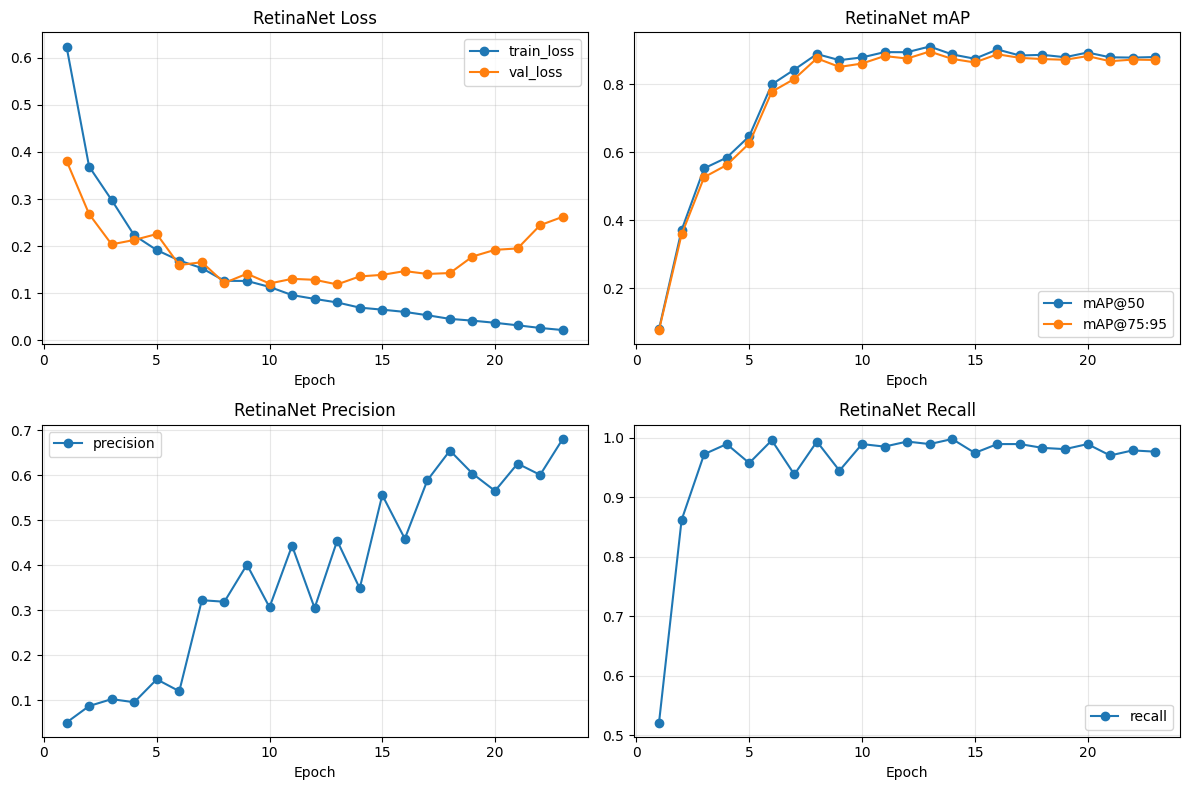

In [9]:
history = load_history("history_retinanet.json")
plot_training_history(history, title_prefix="RetinaNet")

# Threshold Sweep

In [10]:
############################################################
# 6-A. validation threshold sweep (submission style)
############################################################

from collections import defaultdict
import contextlib
import io
import pandas as pd

BEST_MODEL_PATH = "retinanet_oral_drug.pth"
SWEEP_THRESHOLDS = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
SWEEP_TOP_K_PER_IMAGE = 4
model2orig = {v: k for k, v in orig2model.items()}


def filter_submission_style_predictions(
    predictions,
    score_threshold,
    top_k_per_image=4,
):
    by_image = defaultdict(list)

    for pred in predictions:
        if float(pred["score"]) < float(score_threshold):
            continue
        by_image[int(pred["image_id"])].append(pred)

    filtered = []
    for image_id, preds in by_image.items():
        preds = sorted(preds, key=lambda pred: float(pred["score"]), reverse=True)

        if top_k_per_image is not None:
            preds = preds[:int(top_k_per_image)]

        filtered.extend(preds)

    return filtered


if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"best model not found: {BEST_MODEL_PATH}")

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

all_outputs = []
all_image_ids = []

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(DEVICE) for img in images]
        outputs = model(images)

        batch_image_ids = [t["image_id"].item() for t in targets]
        all_outputs.extend(outputs)
        all_image_ids.extend(batch_image_ids)

val_predictions = convert_torchvision_outputs(all_outputs, all_image_ids)

sweep_rows = []

for threshold in SWEEP_THRESHOLDS:
    filtered_predictions = filter_submission_style_predictions(
        val_predictions,
        score_threshold=threshold,
        top_k_per_image=SWEEP_TOP_K_PER_IMAGE,
    )

    with contextlib.redirect_stdout(io.StringIO()):
        metrics = evaluate_all(
            gt_json_path=VAL_JSON_PATH,
            predictions=filtered_predictions,
            conf_threshold=threshold,
            pr_iou_threshold=0.5,
            temp_json_path="retinanet_v10_val_sweep_temp.json",
            model2orig=model2orig,
        )

    sweep_rows.append({
        "score_threshold": threshold,
        "top_k_per_image": SWEEP_TOP_K_PER_IMAGE,
        "num_predictions": len(filtered_predictions),
        "mAP@75:95": metrics["mAP@75:95"],
        "mAP@50": metrics["mAP@50"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
    })

df_sweep = pd.DataFrame(sweep_rows).sort_values(
    by=["mAP@75:95", "mAP@50", "precision"],
    ascending=False,
).reset_index(drop=True)

best_threshold = float(df_sweep.iloc[0]["score_threshold"])
print(f"Best threshold on val: {best_threshold:.2f} (TOP_K={SWEEP_TOP_K_PER_IMAGE})")
df_sweep


Best threshold on val: 0.30 (TOP_K=4)


,score_threshold,top_k_per_image,num_predictions,mAP@75:95,mAP@50,precision,recall
0,0.30,4,584,0.877327,0.891955,0.779110,0.968085
1,0.25,4,595,0.877327,0.891955,0.764706,0.968085
2,0.20,4,596,0.877327,0.891955,0.763423,0.968085
3,0.35,4,571,0.870382,0.885010,0.795096,0.965957
4,0.40,4,551,0.857916,0.871957,0.809437,0.948936
5,0.45,4,527,0.840566,0.854567,0.821632,0.921277
6,0.50,4,478,0.760227,0.773644,0.838912,0.853191


# 추론

In [11]:
############################################################
# 7. test_images -> submission.csv
############################################################

import os
import pandas as pd
from PIL import Image
import torchvision.transforms as T


def letterbox_pil_for_inference(image, target_size=800, fill=(114, 114, 114)):
    orig_w, orig_h = image.size
    scale = target_size / max(orig_w, orig_h)
    new_w = max(1, int(orig_w * scale))
    new_h = max(1, int(orig_h * scale))

    resized = image.resize((new_w, new_h), Image.BILINEAR)
    padded = Image.new("RGB", (target_size, target_size), fill)

    pad_left = (target_size - new_w) // 2
    pad_top = (target_size - new_h) // 2
    padded.paste(resized, (pad_left, pad_top))

    meta = {
        "orig_w": orig_w,
        "orig_h": orig_h,
        "scale": scale,
        "pad_left": pad_left,
        "pad_top": pad_top,
    }
    return padded, meta


def restore_boxes_to_original_xyxy(boxes, meta):
    if boxes.numel() == 0:
        return boxes

    restored = boxes.clone().float()
    restored[:, [0, 2]] = (restored[:, [0, 2]] - meta["pad_left"]) / meta["scale"]
    restored[:, [1, 3]] = (restored[:, [1, 3]] - meta["pad_top"]) / meta["scale"]

    restored[:, [0, 2]] = restored[:, [0, 2]].clamp(0, meta["orig_w"])
    restored[:, [1, 3]] = restored[:, [1, 3]].clamp(0, meta["orig_h"])
    return restored


TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
OUTPUT_CSV_PATH = "/content/pill_detection_project/retinanet_test_submission.csv"
BEST_MODEL_PATH = "retinanet_oral_drug.pth"
LETTERBOX_TARGET_SIZE = 800
DEFAULT_SCORE_THRESHOLD = 0.3
SCORE_THRESHOLD = float(best_threshold) if "best_threshold" in globals() else DEFAULT_SCORE_THRESHOLD
TOP_K_PER_IMAGE = int(SWEEP_TOP_K_PER_IMAGE) if "SWEEP_TOP_K_PER_IMAGE" in globals() else 4
CATEGORY_ID_OFFSET = 1

if not os.path.isdir(TEST_IMG_DIR):
    raise FileNotFoundError(f"test_images folder not found: {TEST_IMG_DIR}")

test_files = sorted(
    f for f in os.listdir(TEST_IMG_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
)

if not test_files:
    raise FileNotFoundError(f"No test images found in: {TEST_IMG_DIR}")

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"best model not found: {BEST_MODEL_PATH}")

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()
rows = []

with torch.no_grad():
    for f in test_files:
        img_path = os.path.join(TEST_IMG_DIR, f)
        image = Image.open(img_path).convert("RGB")
        image_id = os.path.splitext(f)[0]

        letterboxed_image, letterbox_meta = letterbox_pil_for_inference(
            image,
            target_size=LETTERBOX_TARGET_SIZE,
        )

        img_tensor = T.ToTensor()(letterboxed_image).to(DEVICE)
        outputs = model([img_tensor])[0]

        boxes = outputs["boxes"].detach().cpu()
        labels = outputs["labels"].detach().cpu()
        scores = outputs["scores"].detach().cpu()
        boxes = restore_boxes_to_original_xyxy(boxes, letterbox_meta)

        keep = scores >= SCORE_THRESHOLD
        boxes = boxes[keep]
        labels = labels[keep]
        scores = scores[keep]

        if TOP_K_PER_IMAGE is not None and scores.numel() > int(TOP_K_PER_IMAGE):
            scores, topk_idx = scores.topk(int(TOP_K_PER_IMAGE))
            boxes = boxes[topk_idx]
            labels = labels[topk_idx]

        for box, lab, sc in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box.tolist()
            orig_cat = model2orig[int(lab.item())]
            rows.append({
                "image_id": image_id,
                "category_id": int(orig_cat + CATEGORY_ID_OFFSET),
                "bbox_x": float(x1),
                "bbox_y": float(y1),
                "bbox_w": float(x2 - x1),
                "bbox_h": float(y2 - y1),
                "score": float(sc.item()),
            })

if not rows:
    print("No predictions passed the score threshold.")
    df_sub = pd.DataFrame(columns=[
        "annotation_id", "image_id", "category_id",
        "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
    ])
else:
    df_sub = pd.DataFrame(rows, columns=[
        "image_id", "category_id",
        "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
    ])
    df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
    df_sub.insert(0, "annotation_id", range(1, len(df_sub) + 1))

df_sub.to_csv(OUTPUT_CSV_PATH, index=False)

print(f"Saved csv: {OUTPUT_CSV_PATH}")
print(f"Total predicted boxes: {len(df_sub)}")
print(f"Postprocess: score>={SCORE_THRESHOLD:.2f}, TOP_K={TOP_K_PER_IMAGE}")
df_sub.head()


Saved csv: /content/pill_detection_project/retinanet_test_submission.csv
Total predicted boxes: 3281
Postprocess: score>=0.30, TOP_K=4


,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,16551,552.131714,77.276840,405.417786,402.655197,0.716227
1,2,1,1900,156.456345,251.150360,205.237015,127.108704,0.669854
2,3,1,27926,598.082214,668.767212,255.686951,492.367310,0.543702
3,4,1,24850,170.367630,739.159546,184.858780,297.308472,0.419366
4,5,10,21771,643.277954,288.989655,188.825073,182.950134,0.677695


# 시각화

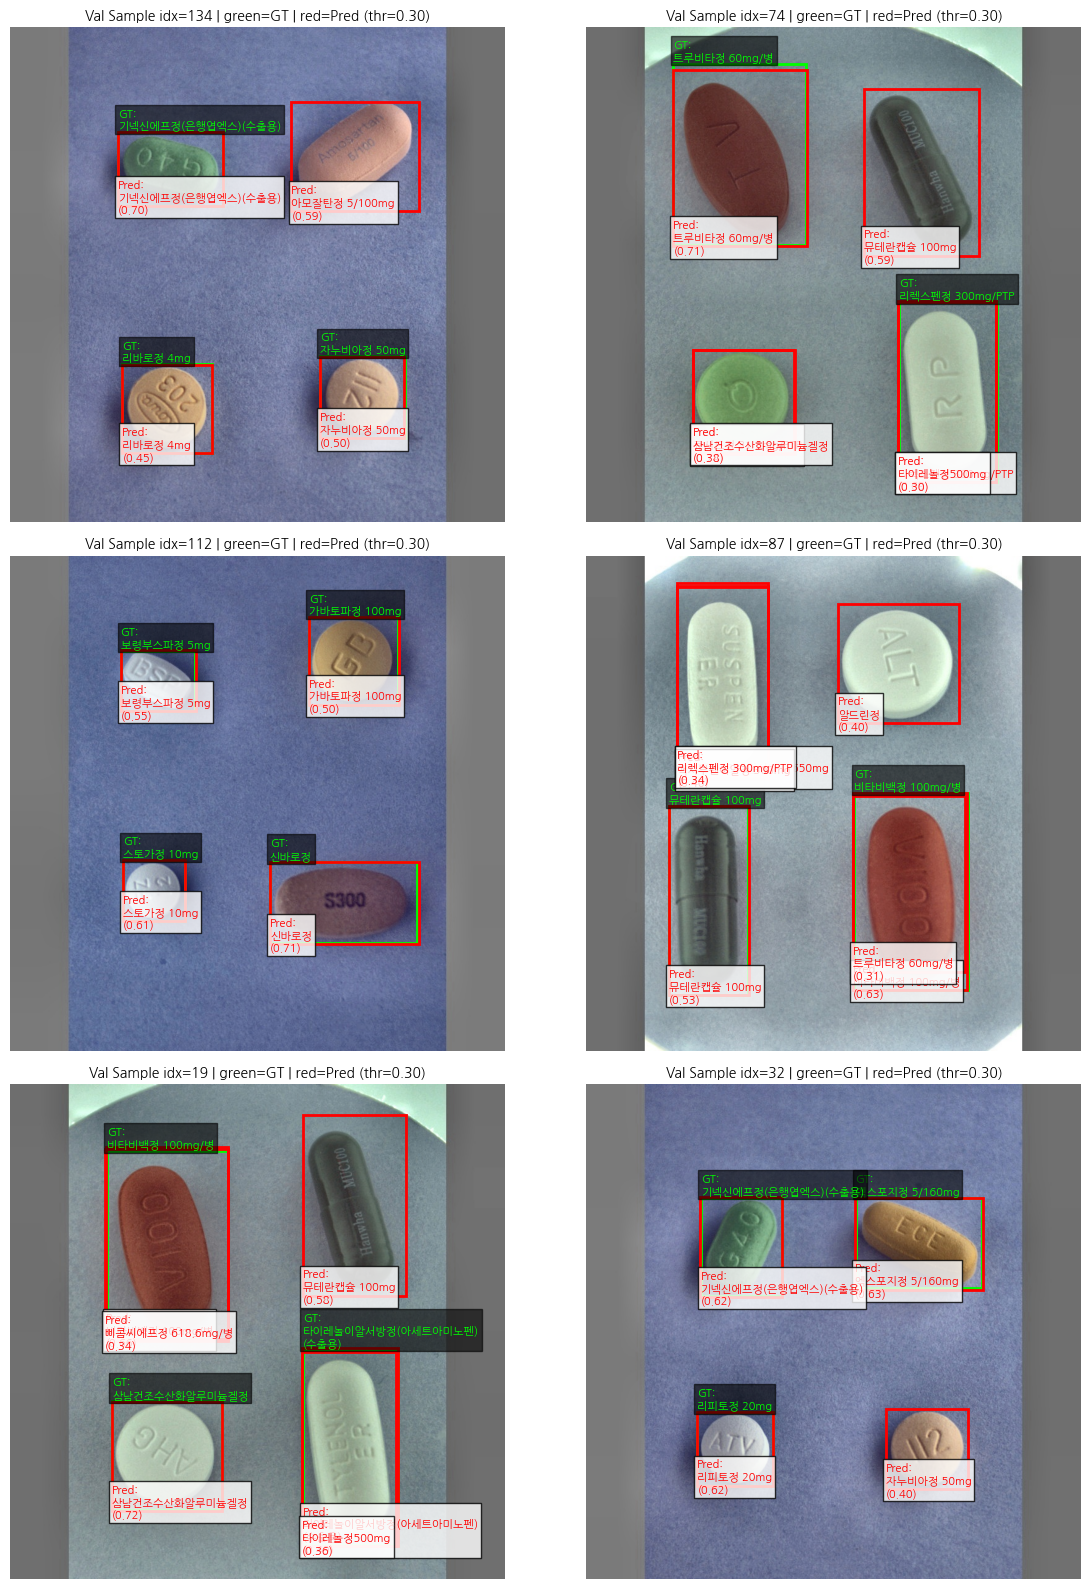

In [12]:
import json
import os
import random
import shutil
import subprocess
import textwrap
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
import torch


def configure_colab_font():
    if shutil.which("apt-get"):
        subprocess.run(
            ["apt-get", "-qq", "install", "-y", "fonts-nanum", "fonts-nanum-extra"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )

    if shutil.which("fc-cache"):
        subprocess.run(
            ["fc-cache", "-fv"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )

    fm._load_fontmanager(try_read_cache=False)
    font_candidates = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    ]

    selected_path = next((path for path in font_candidates if os.path.exists(path)), None)

    if selected_path is not None:
        font_prop = FontProperties(fname=selected_path)
        selected_font = font_prop.get_name()
    else:
        available_fonts = {font.name for font in fm.fontManager.ttflist}
        preferred_fonts = [
            "NanumGothic",
            "NanumBarunGothic",
            "Noto Sans CJK KR",
            "Noto Sans KR",
            "DejaVu Sans",
        ]
        selected_font = next((name for name in preferred_fonts if name in available_fonts), "DejaVu Sans")
        font_prop = FontProperties(family=selected_font)

    plt.rcParams["font.family"] = [selected_font, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return font_prop, selected_font


font_prop, font_name = configure_colab_font()

with open(VAL_JSON_PATH, "r", encoding="utf-8") as f:
    val_coco = json.load(f)

cat_id_to_name = {c["id"]: c["name"] for c in val_coco["categories"]}
model2orig = {v: k for k, v in orig2model.items()}

NUM_SAMPLES = 6
SCORE_THRESH = 0.3
N_COLS = 2
N_ROWS = 3
BEST_MODEL_PATH = "retinanet_oral_drug.pth"


def wrap_label(prefix, name, width=18, score=None):
    wrapped_name = "\n".join(textwrap.wrap(str(name), width=width))
    if score is None:
        return f"{prefix}:\n{wrapped_name}"
    return f"{prefix}:\n{wrapped_name}\n({score:.2f})"


sample_indices = random.sample(
    range(len(val_loader.dataset)),
    k=min(NUM_SAMPLES, len(val_loader.dataset))
)

if os.path.exists(BEST_MODEL_PATH):
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(12, 16))
axes = axes.flatten()

with torch.no_grad():
    for ax, idx in zip(axes, sample_indices):
        image, target = val_loader.dataset[idx]
        output = model([image.to(DEVICE)])[0]

        img_np = image.permute(1, 2, 0).cpu().numpy()
        ax.imshow(img_np)
        ax.axis("off")

        gt_boxes = target["boxes"].cpu().numpy()
        gt_labels = target["labels"].cpu().numpy()

        for box, label in zip(gt_boxes, gt_labels):
            x1, y1, x2, y2 = box
            orig_cat = model2orig.get(int(label), int(label))
            pill_name = cat_id_to_name.get(orig_cat, str(orig_cat))

            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="lime", facecolor="none"
            )
            ax.add_patch(rect)

            ax.text(
                x1, max(y1 - 5, 5),
                wrap_label("GT", pill_name, width=18),
                color="lime",
                fontsize=8,
                bbox=dict(facecolor="black", alpha=0.6, pad=2),
                fontproperties=font_prop
            )

        pred_boxes = output["boxes"].detach().cpu()
        pred_scores = output["scores"].detach().cpu()
        pred_labels = output["labels"].detach().cpu()

        keep = pred_scores >= SCORE_THRESH
        pred_boxes = pred_boxes[keep]
        pred_scores = pred_scores[keep]
        pred_labels = pred_labels[keep]

        for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
            x1, y1, x2, y2 = box.tolist()
            orig_cat = model2orig.get(int(label.item()), int(label.item()))
            pill_name = cat_id_to_name.get(orig_cat, str(orig_cat))

            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)

            ax.text(
                x1, min(y2 + 12, img_np.shape[0] - 5),
                wrap_label("Pred", pill_name, width=18, score=float(score.item())),
                color="red",
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.8, pad=2),
                fontproperties=font_prop
            )

        ax.set_title(
            f"Val Sample idx={idx} | green=GT | red=Pred (thr={SCORE_THRESH:.2f})",
            fontproperties=font_prop,
        )

for ax in axes[len(sample_indices):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# 가중치 및 학습 결과 구글 드라이브에 저장

In [13]:
import os
import shutil

SAVE_DIR = "/content/drive/MyDrive/pill_detection_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy("/content/pill_detection_project/retinanet_oral_drug.pth", SAVE_DIR)
shutil.copy("/content/pill_detection_project/history_retinanet.json", SAVE_DIR)
shutil.copy("/content/pill_detection_project/retinanet_test_submission.csv", SAVE_DIR)

print(os.listdir(SAVE_DIR))

['retinanet_oral_drug.pth', 'history_retinanet.json', 'retinanet_test_submission.csv']


In [14]:
import requests

webhook_url = "https://discord.com/api/webhooks/1484101399792058379/RmmWK-rC4qJhpDUJtgO9OwEwMzLuUJ-_NNp62V33g1_Cny5sg13MhOE4RV3sMCy8D4M5"
data = {"content": "RetinaNet 학습이 완료됐습니다."}
requests.post(webhook_url, json=data)


<Response [204]>